In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("wine.data", header=None)

In [4]:
X = df.iloc[:, 1:]

In [5]:
X_scaled = StandardScaler().fit_transform(X)

In [6]:
wcss = []
for k in range(2, 11):
    wcss.append(KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X_scaled).inertia_)

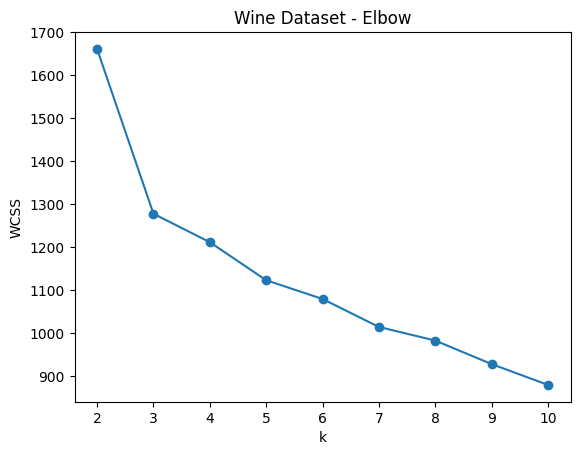

In [7]:

plt.plot(range(2, 11), wcss, marker="o")
plt.title("Wine Dataset - Elbow")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.show()

In [8]:
k = 3
model = KMeans(n_clusters=k, random_state=42, n_init="auto")
df["Cluster"] = model.fit_predict(X_scaled)

In [9]:
print("Silhouette Score:", round(silhouette_score(X_scaled, df["Cluster"]), 4))

Silhouette Score: 0.2849


In [10]:
df.to_csv("wine_clustered.csv", index=False)
print("Saved: wine_clustered.csv")

Saved: wine_clustered.csv


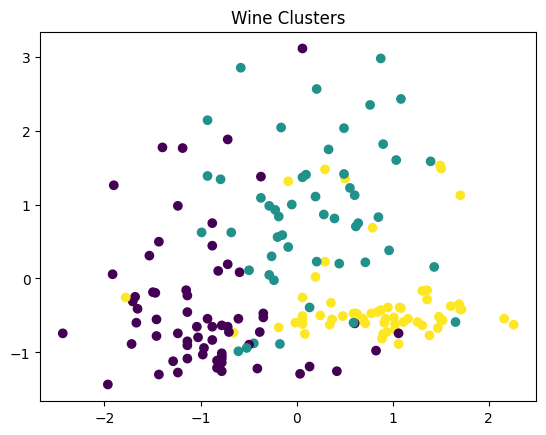

In [11]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["Cluster"])
plt.title("Wine Clusters")
plt.show()